<a href="https://colab.research.google.com/github/poojasnair2428/Code-a-Pookalam/blob/main/pookalam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

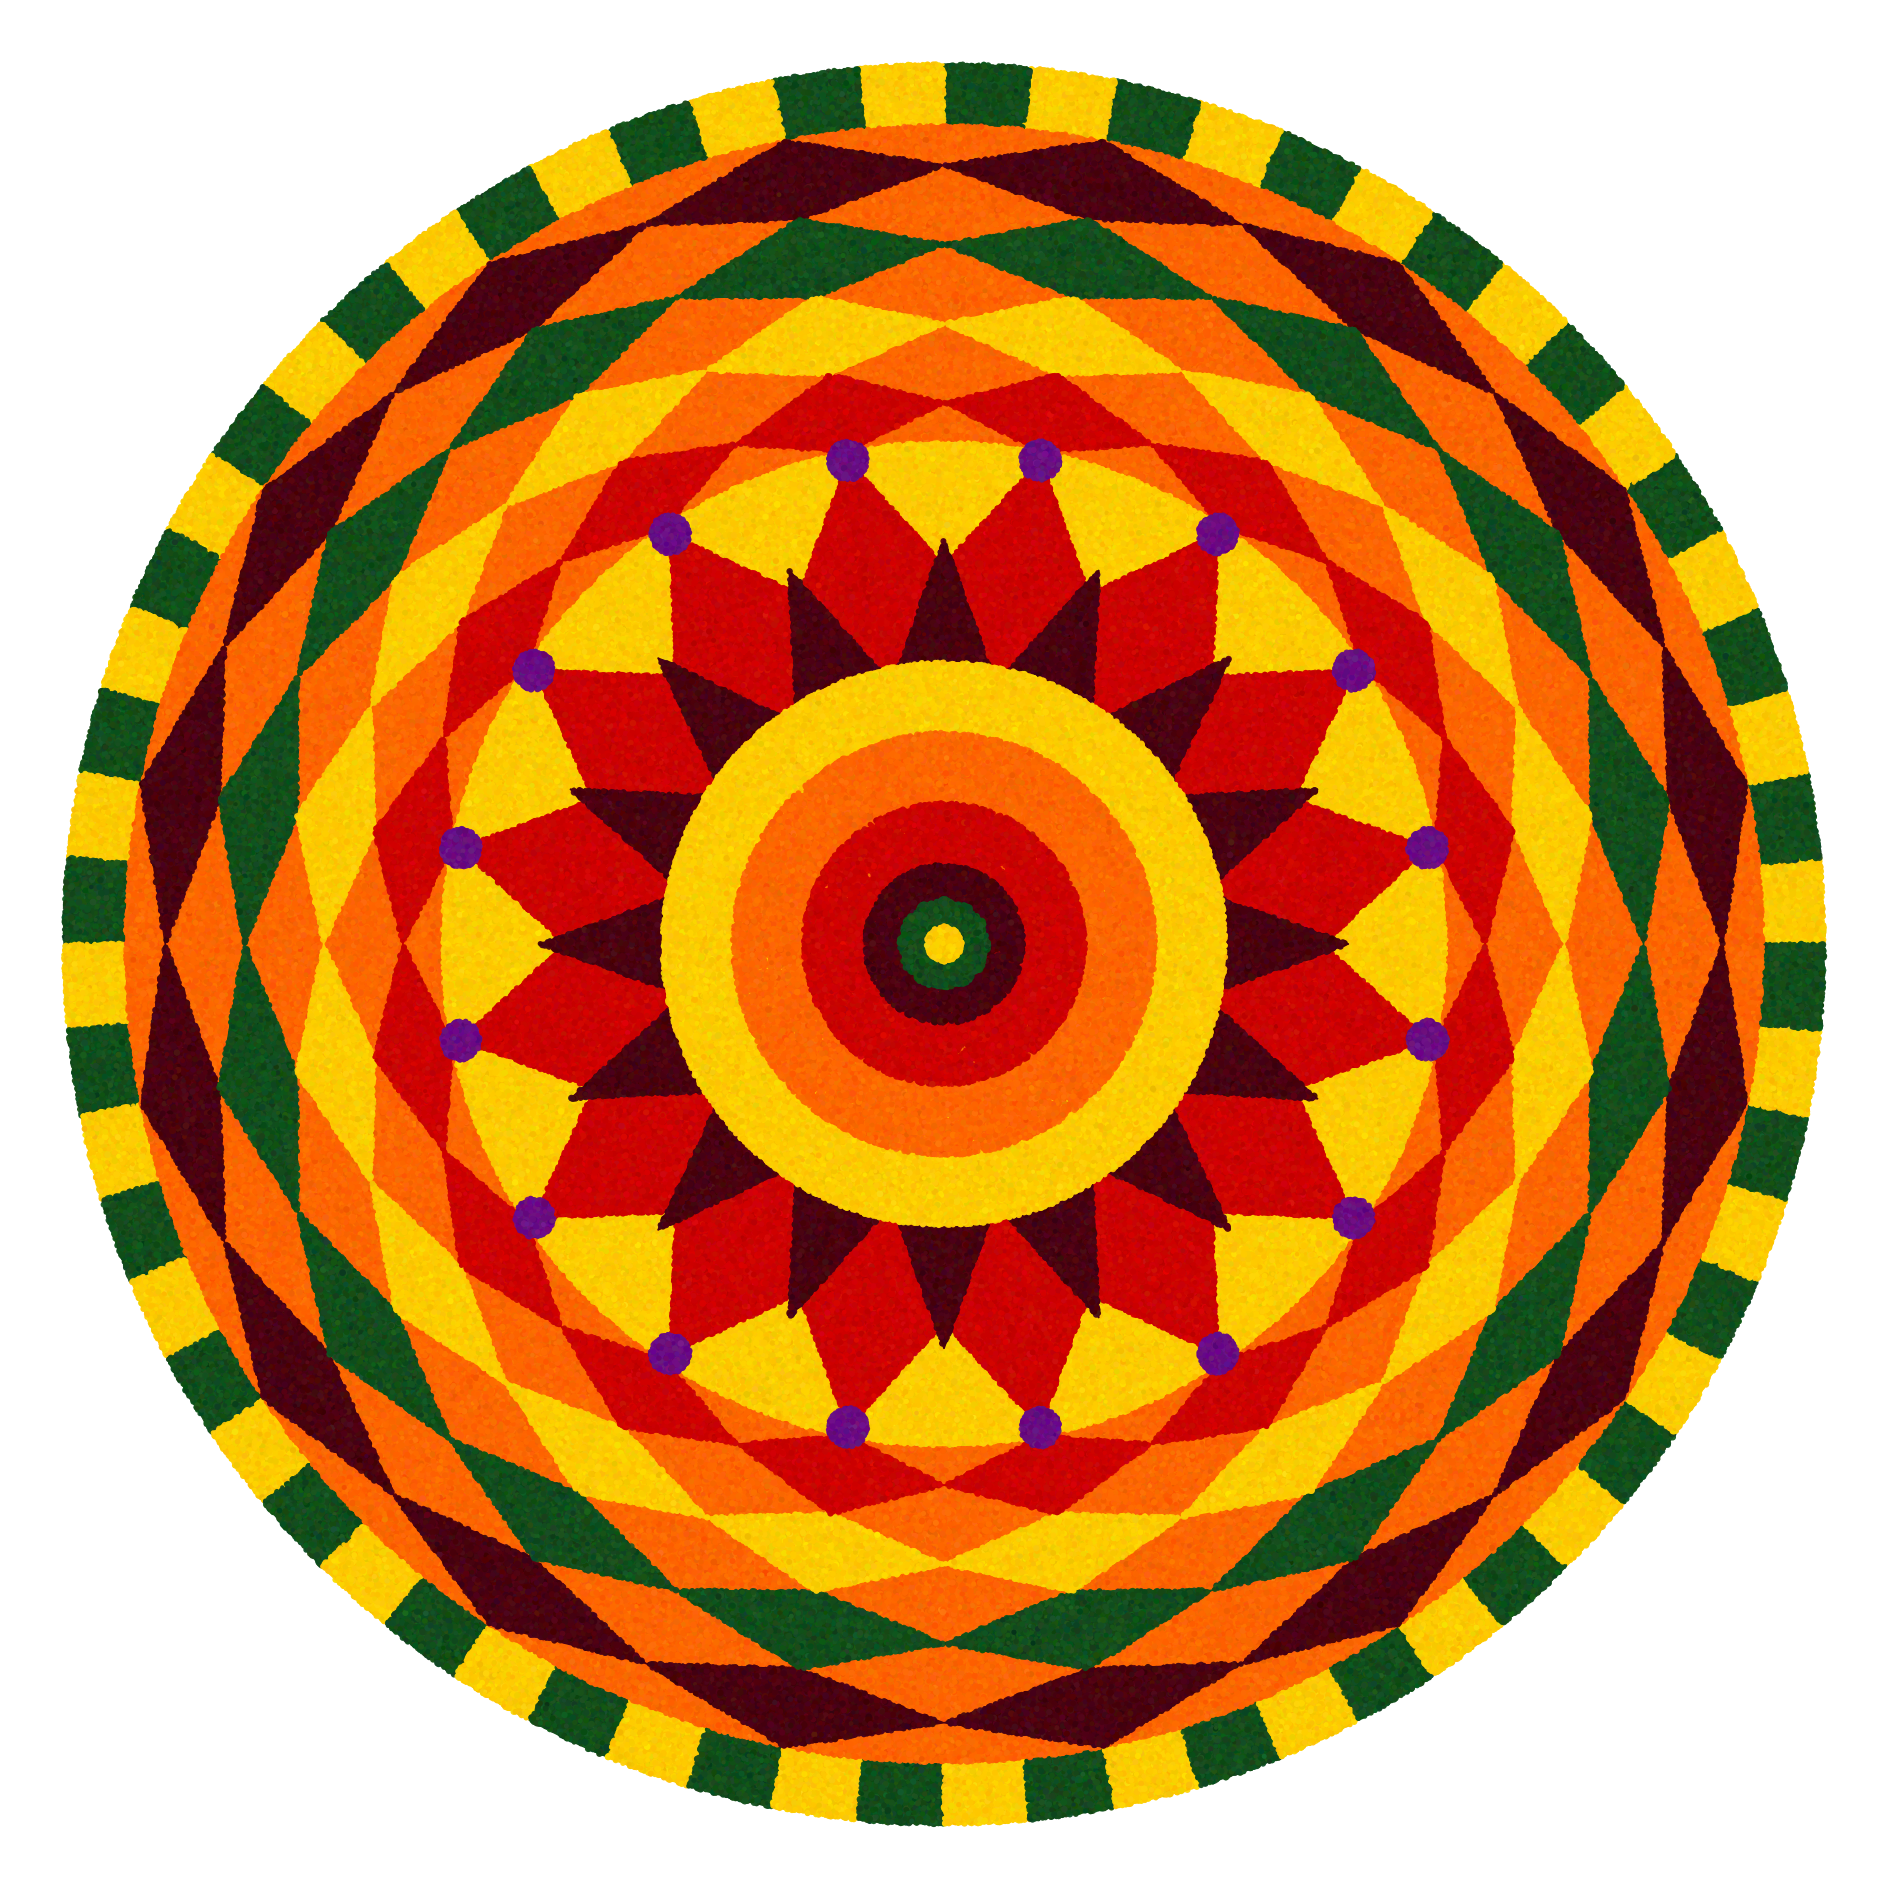

In [52]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

# Configure plot for high quality rendering with a white background
fig, ax = plt.subplots(figsize=(12, 12), dpi=200)
ax.set_aspect("equal")
ax.axis("off")
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

np.random.seed(42)

# Color Palette (Rich, saturated floral shades)
C_GREEN = "#134e1c"
C_YELLOW = "#ffcc00"
C_ORANGE = "#ff6600"
C_RED = "#cc0000"
C_MAROON = "#4a0011"
C_PURPLE = "#6a0d83"


# --- Helper Function for Dense Floral Textures ---
def add_solid_and_petals(
    ax, shape_x, shape_y, base_color, density=1.5, zorder=1
):
    """Draws a rich solid base with thousands of dense floral particles for high saturation."""
    # 1. Base solid polygon to ensure zero transparency/black gaps
    poly = patches.Polygon(
        np.column_stack([shape_x, shape_y]),
        closed=True,
        facecolor=base_color,
        edgecolor=base_color,
        linewidth=0.5,
        zorder=zorder,
    )
    ax.add_patch(poly)

    # 2. Add dense scatter points to mimic crushed flower texture
    poly_path = poly.get_path()
    min_x, max_x = np.min(shape_x), np.max(shape_x)
    min_y, max_y = np.min(shape_y), np.max(shape_y)

    area = (max_x - min_x) * (max_y - min_y)
    num_particles = int(area * density * 1200)

    if num_particles <= 0:
        return

    rx = np.random.uniform(min_x, max_x, num_particles)
    ry = np.random.uniform(min_y, max_y, num_particles)
    points = np.column_stack([rx, ry])

    inside = poly_path.contains_points(points)
    px, py = rx[inside], ry[inside]

    if len(px) == 0:
        return

    # Subtly alter colors for organic texture depth
    base_rgb = np.array(plt.cm.colors.to_rgb(base_color))
    color_noise = np.random.normal(0, 0.03, (len(px), 3))
    colors = np.clip(base_rgb + color_noise, 0, 1)

    ax.scatter(
        px,
        py,
        s=np.random.uniform(2.0, 6.0, size=len(px)),
        c=colors,
        marker="o",
        alpha=0.95,
        linewidths=0,
        zorder=zorder + 0.1,
    )


# --- 1. Outer Border Ring (Alternating Yellow & Green Blocks) ---
num_border_blocks = 64
for i in range(num_border_blocks):
    a1 = 2 * np.pi * i / num_border_blocks
    a2 = 2 * np.pi * (i + 1) / num_border_blocks
    color = C_YELLOW if i % 2 == 0 else C_GREEN

    t = np.linspace(a1, a2, 10)
    x_out, y_out = 10.0 * np.cos(t), 10.0 * np.sin(t)
    x_in, y_in = 9.3 * np.cos(t[::-1]), 9.3 * np.sin(t[::-1])

    sx = np.concatenate([x_out, x_in])
    sy = np.concatenate([y_out, y_in])

    add_solid_and_petals(ax, sx, sy, color, density=2.0, zorder=1)

# --- 2. Interlocking Curved Diamond Outer Mesh Ring ---
N_DIAMONDS = 16

# ADD THIS LINE: Fill the background of the diamond mesh area with yellow
theta_mesh = np.linspace(0, 2 * np.pi, 120)
x_mesh = np.concatenate(
    [9.3 * np.cos(theta_mesh), 5.7 * np.cos(theta_mesh[::-1])]
)
y_mesh = np.concatenate(
    [9.3 * np.sin(theta_mesh), 5.7 * np.sin(theta_mesh[::-1])]
)
add_solid_and_petals(ax, x_mesh, y_mesh, C_ORANGE, density=1.5, zorder=1.5)

# Keep the loop unchanged right below it
diamond_layers = [
    (9.3, 8.4, C_MAROON),
    (8.4, 7.5, C_GREEN),
    (7.5, 6.6, C_YELLOW),
    (6.6, 5.7, C_RED),
]
for r_top, r_bot, color in diamond_layers:
    for i in range(N_DIAMONDS):
        a1 = 2 * np.pi * i / N_DIAMONDS
        a_mid = 2 * np.pi * (i + 0.5) / N_DIAMONDS
        a2 = 2 * np.pi * (i + 1) / N_DIAMONDS

        x = [
            r_top * np.cos(a_mid),
            (r_top + r_bot) / 2 * np.cos(a2),
            r_bot * np.cos(a_mid),
            (r_top + r_bot) / 2 * np.cos(a1),
        ]
        y = [
            r_top * np.sin(a_mid),
            (r_top + r_bot) / 2 * np.sin(a2),
            r_bot * np.sin(a_mid),
            (r_top + r_bot) / 2 * np.sin(a1),
        ]

        add_solid_and_petals(ax, x, y, color, density=1.8, zorder=2)

# --- 3. Middle Yellow Petal Field Ring ---
theta = np.linspace(0, 2 * np.pi, 120)
x_yell = np.concatenate([5.7 * np.cos(theta), 4.3 * np.cos(theta[::-1])])
y_yell = np.concatenate([5.7 * np.sin(theta), 4.3 * np.sin(theta[::-1])])
add_solid_and_petals(ax, x_yell, y_yell, C_YELLOW, density=1.5, zorder=3)

# --- 4. Double Layered Pointed Star Burst ---
N_STAR = 16

# Outer White Star
for i in range(N_STAR):
    a1 = 2 * np.pi * i / N_STAR
    a_mid = a1 + np.pi / N_STAR
    a2 = 2 * np.pi * (i + 1) / N_STAR

    sx = [4.3 * np.cos(a1), 5.6 * np.cos(a_mid), 4.3 * np.cos(a2), 0]
    sy = [4.3 * np.sin(a1), 5.6 * np.sin(a_mid), 4.3 * np.sin(a2), 0]

    add_solid_and_petals(ax, sx, sy, C_RED, density=2.0, zorder=4)

# Inner Maroon Star Offset
for i in range(N_STAR):
    a1 = 2 * np.pi * i / N_STAR + (np.pi / N_STAR)
    a_mid = a1 + np.pi / N_STAR
    a2 = 2 * np.pi * (i + 1) / N_STAR + (np.pi / N_STAR)

    sx = [3.0 * np.cos(a1), 4.6 * np.cos(a_mid), 3.0 * np.cos(a2), 0]
    sy = [3.0 * np.sin(a1), 4.6 * np.sin(a_mid), 3.0 * np.sin(a2), 0]

    add_solid_and_petals(ax, sx, sy, C_MAROON, density=2.0, zorder=5)

# --- 5. Purple Accent Balls ---
for i in range(N_STAR):
    a = 2 * np.pi * i / N_STAR + (np.pi / N_STAR)
    cx, cy = 5.6 * np.cos(a), 5.6 * np.sin(a)
    r_dot = np.linspace(0, 2 * np.pi, 30)
    add_solid_and_petals(
        ax,
        cx + 0.22 * np.cos(r_dot),
        cy + 0.22 * np.sin(r_dot),
        C_PURPLE,
        density=3.0,
        zorder=6,
    )

# --- 6. Inner Concentric Floral Core ---
radii_colors = [
    (3.2, C_YELLOW),
    (2.4, C_ORANGE),
    (1.6, C_RED),
    (0.9, C_MAROON),
]

for r, col in radii_colors:
    x_c = r * np.cos(theta)
    y_c = r * np.sin(theta)
    add_solid_and_petals(ax, x_c, y_c, col, density=2.0, zorder=7)

# --- 7. Centerpiece Flower ---
for i in range(12):
    a = 2 * np.pi * i / 12
    cx, cy = 0.35 * np.cos(a), 0.35 * np.sin(a)
    add_solid_and_petals(
        ax,
        cx + 0.16 * np.cos(theta),
        cy + 0.16 * np.sin(theta),
        C_GREEN,
        density=3.0,
        zorder=8,
    )

# Center Red Core
add_solid_and_petals(
    ax, 0.2 * np.cos(theta), 0.2 * np.sin(theta), C_YELLOW, density=3.0, zorder=9
)

# Set Canvas Limits
ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)

plt.show()